# ZINC Non-Streaming Demo

This notebook mirrors the lean streaming demo, but uses the regular in-memory `fit(...)` path.

- source: raw ZINC CSV
- sample limit: `0.1`
- fit mode: materialize sampled graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import random

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

from conditional_node_field_graph_generator.notebooks import configure_notebook, download_zinc_dataset
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from abstractgraph_graphicalizer.chem import draw_molecule, draw_molecules
from conditional_node_field_graph_generator.input_sources import iter_selected_source_graphs
from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.extensions.demo.visualization import plot_networkx_graphs
from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator


Enabling RDKit 2025.09.3 jupyter extensions


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


PyTorch version: 2.2.2
CUDA available: False


In [3]:
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_SIZE = 'zinc15'
ZINC_FILENAME = f'{ZINC_SIZE}.csv'
RANDOM_SEED = 42
DATA_LIMIT = 5000
FIT_BATCH_SIZE = 64
MAXIMUM_EPOCHS = 350

# First-pass anti-saturation knobs: keep capacity fixed, increase score signal.
EMBEDDING_DIM = 64
LEARNING_RATE = 2e-4
SPARSE_SUPERVISION_MASK_RATIO = 0.5

# Capacity knobs. Increase only after the dense-signal run still plateaus.
NUMBER_OF_TRANSFORMER_LAYERS = 3
TRANSFORMER_ATTENTION_HEAD_COUNT = 4
TRANSFORMER_DROPOUT = 0.1

# Structural supervision weights.
LAMBDA_DEGREE_IMPORTANCE = 4.0
LAMBDA_NODE_LABEL_IMPORTANCE = 3.0
LAMBDA_EDGE_LABEL_IMPORTANCE = 3.0
LAMBDA_DIRECT_EDGE_IMPORTANCE = 3.0
LAMBDA_AUXILIARY_EDGE_IMPORTANCE = 2.0

MODEL_NAME = (
    f'{ZINC_SIZE}-nonstreaming-d{EMBEDDING_DIM}-s{DATA_LIMIT}'
    f'-b{FIT_BATCH_SIZE}-lr{LEARNING_RATE:g}-mask{SPARSE_SUPERVISION_MASK_RATIO:g}'
    f'-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [4]:
csv_path = download_zinc_dataset(ZINC_DATA_ROOT, filename=ZINC_FILENAME)
print(f'ZINC CSV: {csv_path}')

graphs = list(
    iter_selected_source_graphs(
        csv_path,
        'zinc_csv',
        limit=DATA_LIMIT,
        random_state=RANDOM_SEED,
    )
)
print(f'Loaded {len(graphs)} graphs into memory for non-streaming fit.')

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=NUMBER_OF_TRANSFORMER_LAYERS,
    transformer_attention_head_count=TRANSFORMER_ATTENTION_HEAD_COUNT,
    transformer_dropout=TRANSFORMER_DROPOUT,
    locality_horizon=2,
    sparse_supervision_mask_ratio=SPARSE_SUPERVISION_MASK_RATIO,
    learning_rate=LEARNING_RATE,
    lambda_degree_importance=LAMBDA_DEGREE_IMPORTANCE,
    lambda_node_label_importance=LAMBDA_NODE_LABEL_IMPORTANCE,
    lambda_edge_label_importance=LAMBDA_EDGE_LABEL_IMPORTANCE,
    lambda_direct_edge_importance=LAMBDA_DIRECT_EDGE_IMPORTANCE,
    lambda_auxiliary_edge_importance=LAMBDA_AUXILIARY_EDGE_IMPORTANCE,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.graph_decoder.diagnostic_graph_renderer = draw_molecules

TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS = {
    'size': (500, 350),
    'cell_size': 2.8,
    'title_font_size': 8,
}


ZINC CSV: /Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/notebooks/datasets/zinc/zinc15.csv
Loaded 5000 graphs into memory for non-streaming fit.
Configured graph generator model_name=zinc15-nonstreaming-d64-s5000-b64-lr0-0002-mask0-5-e350 model_dir=/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/saved_generators


Fit target model_name=zinc15-nonstreaming-d64-s5000-b64-lr0-0002-mask0-5-e350 model_dir=/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/saved_generators
Fitting model on 5000 graphs
Fitted node embedding SVD: 2048 -> 64.
Fitted graph embedding SVD: 2048 -> 64.
Fitting feasibility estimator on 5000 graphs
Finished fitting feasibility estimator in 2m 56.3s
Supervision plan:
  node_labels: mode=learned, enabled. 9 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=learned, enabled, horizon=2. Use horizon-2 locality as auxiliary regularization.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 422207 pairs (50.00%) from 844414 total pairs (pos=281800, neg=562614, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, 

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Epoch 10/350 | ETA 7h 15m 01s:
  train total=   52.848 | node_field    22.408 [42.4%] |        deg    2.8373 [5.4%] |      exist   0.12238 [0.2%] | node_count   0.00172 [<0.1%]
  val   total=   53.487 | node_field    22.275 [41.6%] |        deg    2.7457 [5.1%] |      exist   0.11588 [0.2%] | node_count   0.00160 [<0.1%]
  train                 | node_label    1.0685 [2.0%] | edge_label    1.0671 [2.0%] |       edge    2.6172 [5.0%] | edge_count    21.182 [40.1%] | deg_edge_consistency   0.00037 [<0.1%]
  val                   | node_label   0.94000 [1.8%] | edge_label   0.97697 [1.8%] |       edge    2.5809 [4.8%] | edge_count    22.321 [41.7%] | deg_edge_consistency   0.00033 [<0.1%]
  train                 |        aux    1.5423 [2.9%] | dominant=node_field [42.4%]
  val                   |        aux    1.5294 [2.9%] | dominant=edge_count [41.7%]
Epoch 20/350 | ETA 5h 51m 54s:
  train total=   49.784 | node_field    22.055 [44.3%] |        deg    2.4899 [5.0%] |      exist   0.1112

[21:04:49] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.


Epoch 40/350 | ETA 5h 17m 56s:
  train total=   46.085 | node_field    21.521 [46.7%] |        deg    2.1070 [4.6%] |      exist   0.09051 [0.2%] | node_count   0.00122 [<0.1%]
  val   total=   45.693 | node_field    21.333 [46.7%] |        deg    2.0521 [4.5%] |      exist   0.08609 [0.2%] | node_count   0.00111 [<0.1%]
  train                 | node_label   0.65795 [1.4%] | edge_label   0.62289 [1.4%] |       edge    2.3737 [5.2%] | edge_count    17.301 [37.5%] | deg_edge_consistency   0.00025 [<0.1%]
  val                   | node_label   0.60505 [1.3%] | edge_label   0.58380 [1.3%] |       edge    2.3051 [5.0%] | edge_count    17.355 [38.0%] | deg_edge_consistency   0.00026 [<0.1%]
  train                 |        aux    1.4095 [3.1%] | dominant=node_field [46.7%]
  val                   |        aux    1.3707 [3.0%] | dominant=node_field [46.7%]
Epoch 50/350 | ETA 5h 03m 14s:
  train total=   44.828 | node_field    21.345 [47.6%] |        deg    2.0050 [4.5%] |      exist   0.0815

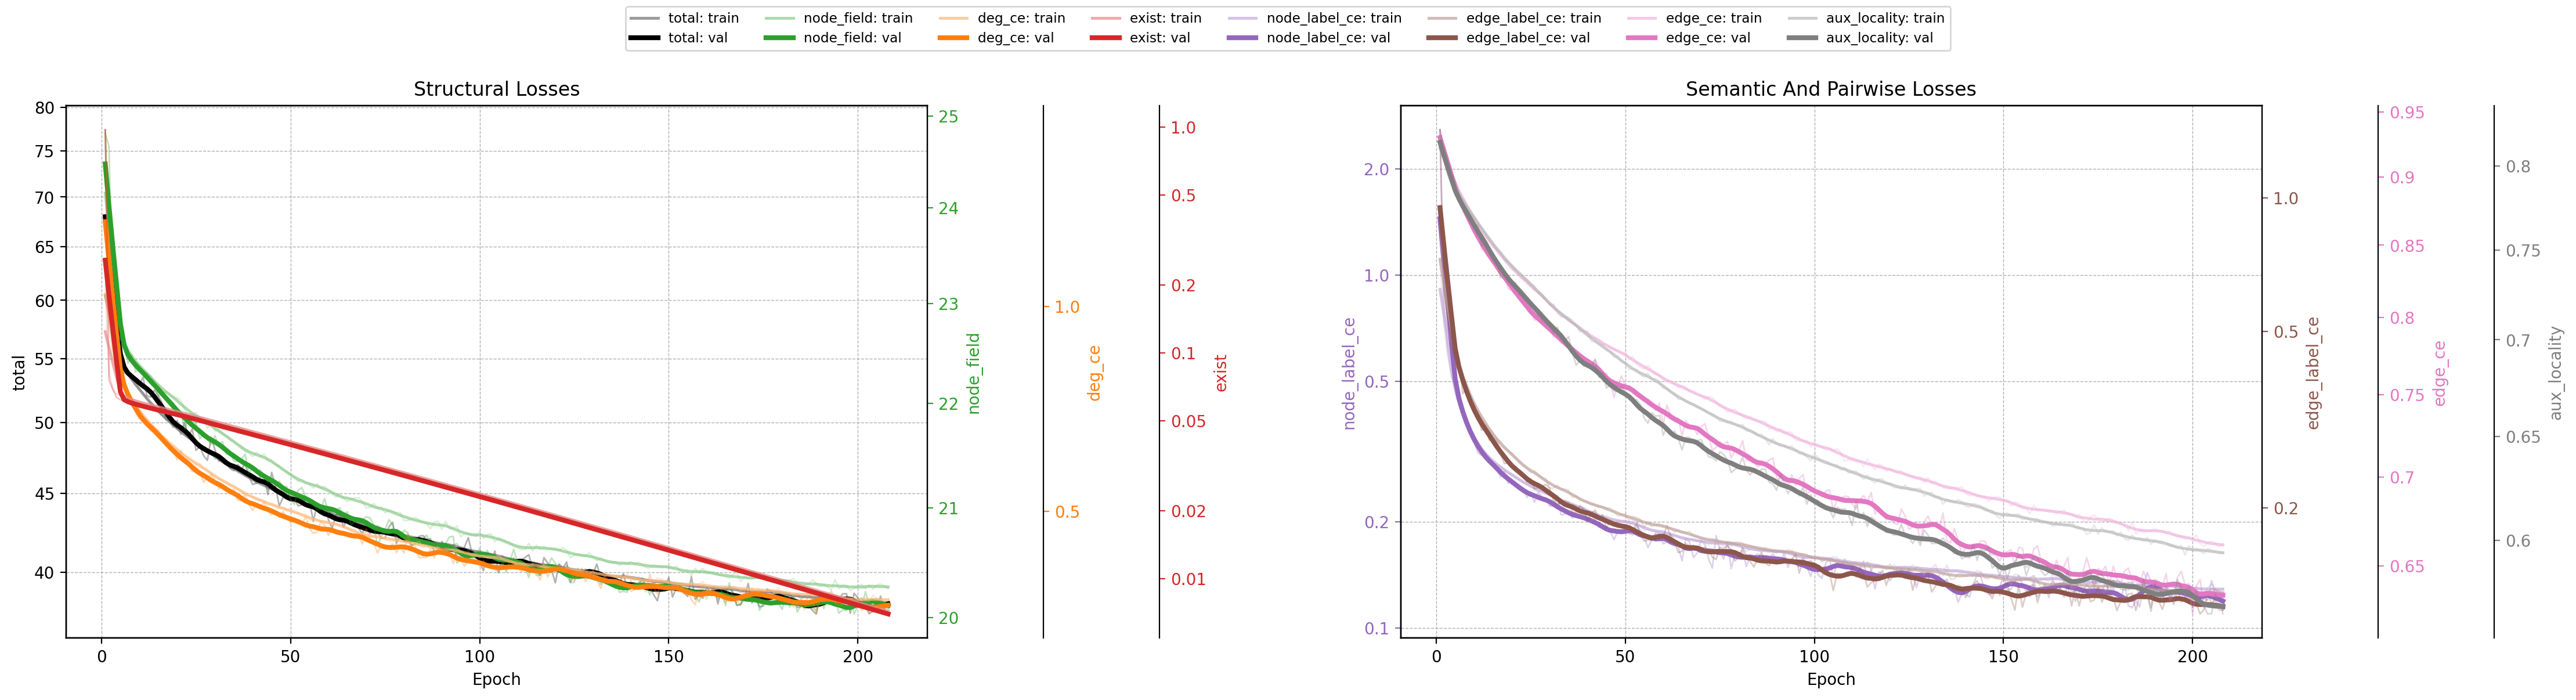

training_graph_conditioning_ = 5000
is_fitted_ = True


In [11]:
graph_generator.fit(
    graphs,
    train_node_generator=True,
    targets=None,
    sample_training_progress=True,
    sample_training_progress_n_samples=1,
    sample_training_progress_every_n_epochs=10,
    sample_training_progress_plot_kwargs=TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS,
    sample_training_progress_plot_fn=draw_molecule,
)

print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


In [5]:
#load model
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)
SAVED_GENERATOR_ROOT = REPO_ROOT / '.artifacts' / 'saved_generators'
list_saved_graph_generators(SAVED_GENERATOR_ROOT)
#MODEL_NAME = 'zinc20-nonstreaming-d64-s0-99-b128-e350.pkl'
graph_generator = load_graph_generator(MODEL_NAME+'.pkl', model_dir=SAVED_GENERATOR_ROOT)

,name,modified,size_mb
0,zinc15-nonstreaming-d64-s5000-b64-lr0-0002-mas...,2026-05-31 01:44,7.9
1,artificial-cycle-path-star-n5000-c5-p3-r2x1-d6...,2026-05-31 01:30,7.9
2,artificial-cycle-path-star-n3000-c5-p3-r2x1-d6...,2026-05-30 20:05,6.8
3,zinc15-nonstreaming-d64-s2000-b64-lr0-0002-mas...,2026-05-30 19:52,6.4
4,zinc15-nonstreaming-d64-s1500-b128-e350.pkl,2026-05-27 18:41,6.1


Loaded graph generator: zinc15-nonstreaming-d64-s5000-b64-lr0-0002-mask0-5-e350.pkl
/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/NodeField/.artifacts/saved_generators/zinc15-nonstreaming-d64-s5000-b64-lr0-0002-mask0-5-e350.pkl


Non-streaming ZINC raw samples


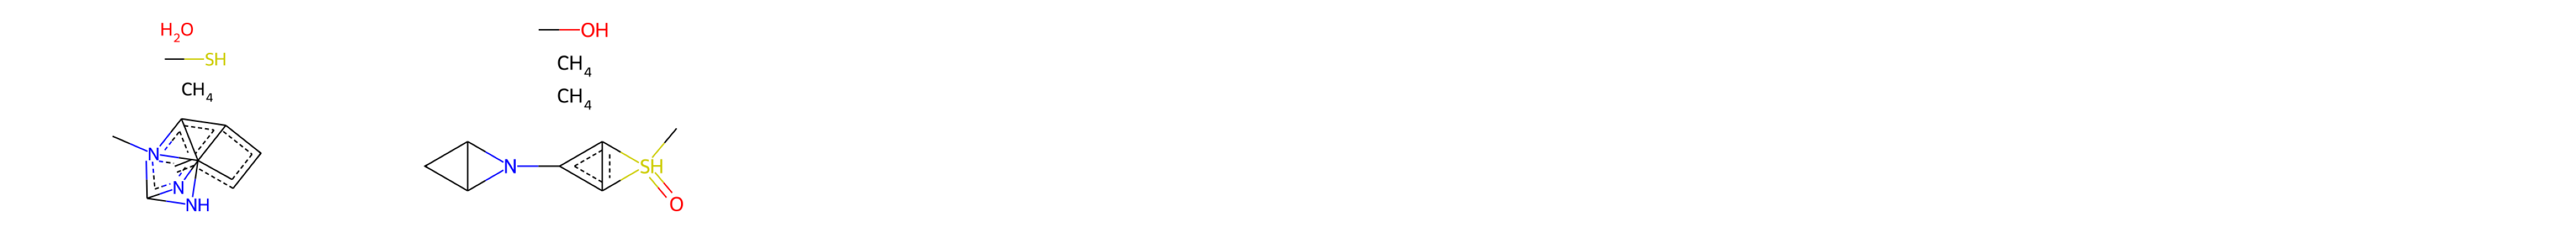

Non-streaming ZINC ILP samples


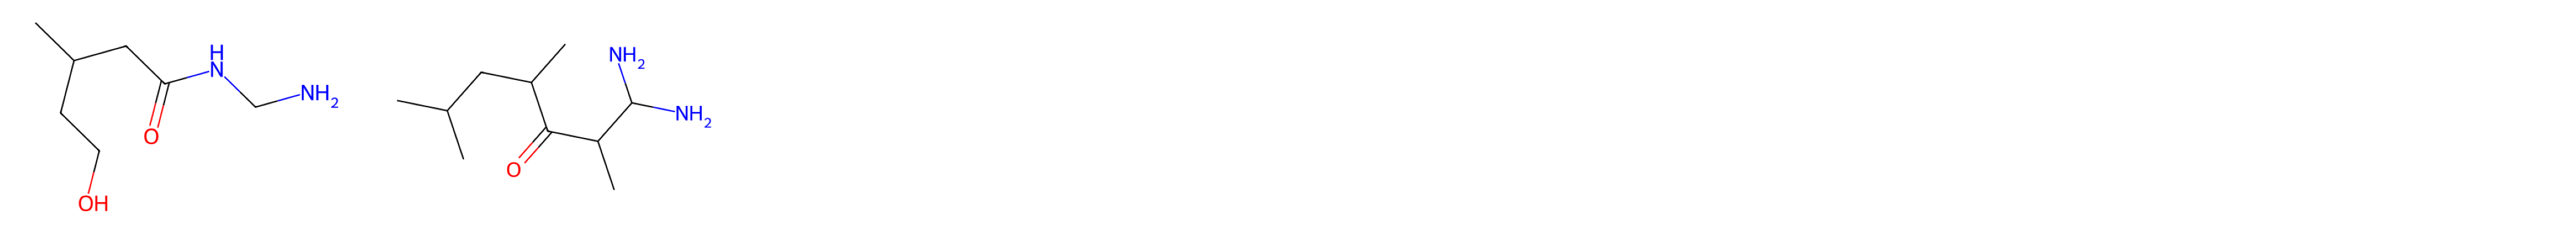

Non-streaming ZINC Oracle samples


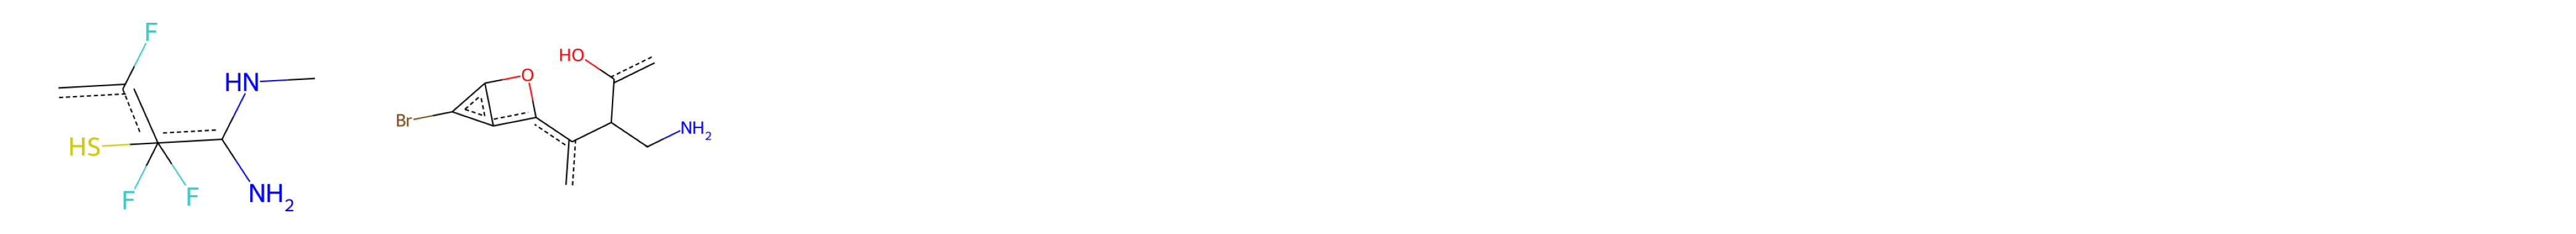

In [8]:
n_samples = 3
raw_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=False,
    use_ilp_decoder=False,
)
show_molecules(raw_samples, n=n_samples, title='Non-streaming ZINC raw samples')

ilp_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=False,
    use_ilp_decoder=True,
)
show_molecules(ilp_samples, n=n_samples, title='Non-streaming ZINC ILP samples')

oracle_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=False,
    use_ilp_decoder=True,
    use_feasibility_oracle=True,
)
show_molecules(oracle_samples, n=n_samples, title='Non-streaming ZINC Oracle samples')


Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=4m 29.9s | eta=1h 25m 28.3s
Feasibility attempt  2/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=2m 02.0s | eta=58m 47.3s
Feasibility attempt  3/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=   56.3s | eta=42m 20.0s
Feasibility attempt  4/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 12.0s | eta=34m 41.1s
Feasibility attempt  5/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 09.3s | eta=29m 28.6s
Feasibility attempt  6/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 03.4s | eta=25m 23.5s
Feasibility attempt  7/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 06.4s | eta=22m 15.9s
Feasibility attempt  8/20 | generated=   8 | feasible_candidates= 0 | feasible_r

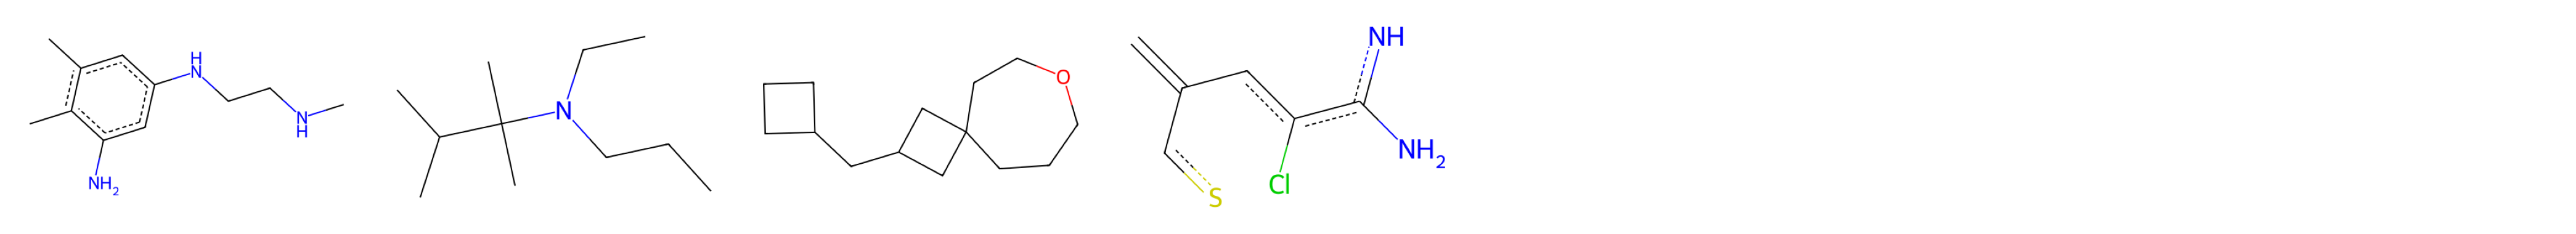

In [14]:
if graph_generator.feasibility_estimator is None:
    raise RuntimeError('Feasibility estimator is unavailable in this environment.')

filtered_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=True,
)
show_molecules(filtered_samples, n=n_samples, title='Non-streaming ZINC samples with feasibility filtering')
